In [30]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

In [31]:
import numpy as np

def plot_decision_boundary(clf, X, y):
    x1s = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    x2s = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.xlabel("Petal length")
    plt.ylabel("Petal width")

In [32]:
#Q1(a)
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=0)
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=0)

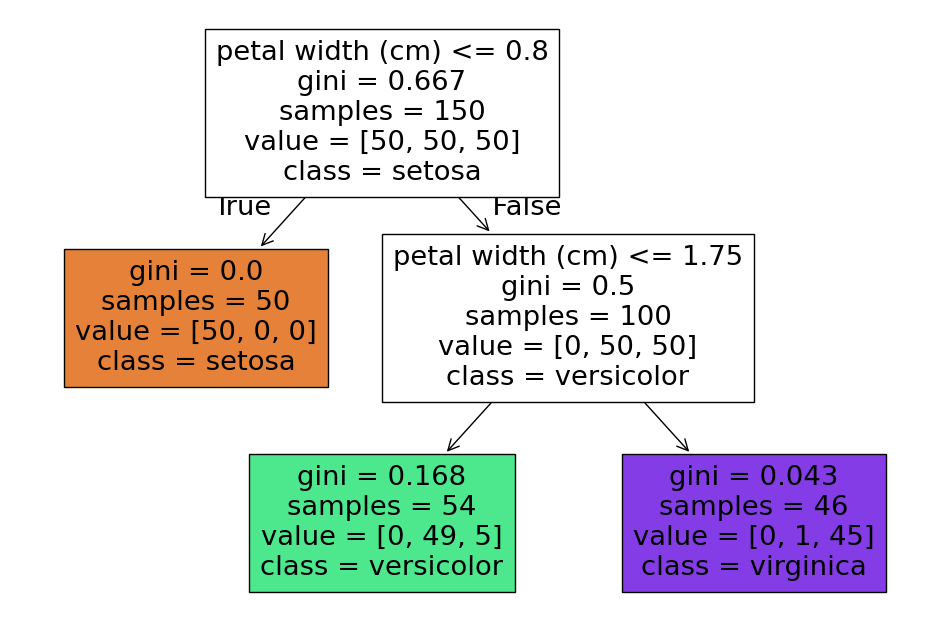

In [41]:
#Q1(b)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(
    tree_clf,
    feature_names=["petal length (cm)", "petal width (cm)"],  
    class_names=iris.target_names, 
    filled=True
)
plt.show()

The root node uses **feature2** for the first split. This means that feature2 provides the highest reduction in impurity at the initial step, making it the most important feature for separating the classes at the root level of the tree.

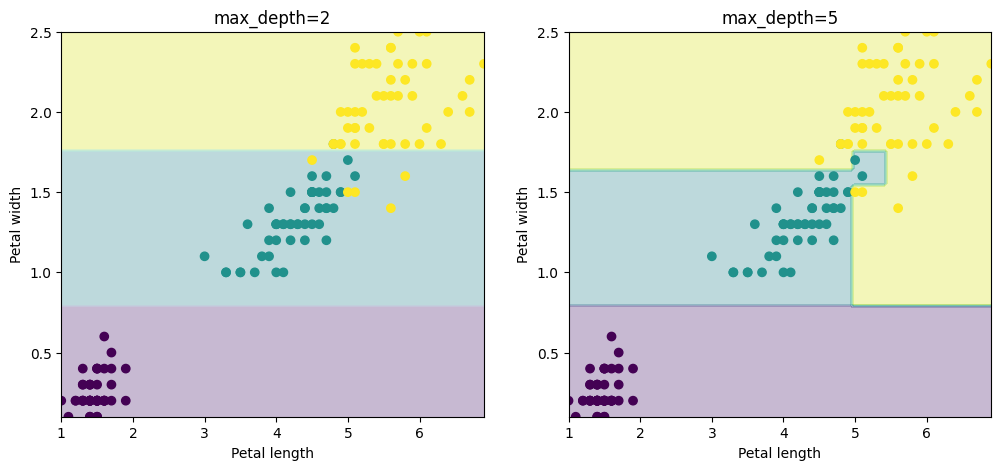

In [34]:
#Q2
tree_depth2 = DecisionTreeClassifier(max_depth=2, random_state=0)
tree_depth5 = DecisionTreeClassifier(max_depth=5, random_state=0)

tree_depth2.fit(X, y)
tree_depth5.fit(X, y)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(tree_depth2, X, y)
plt.title("max_depth=2")

plt.subplot(1, 2, 2)
plot_decision_boundary(tree_depth5, X, y)
plt.title("max_depth=5")

plt.show()

The model with max_depth=5 is more complex than the model with max_depth=2 because it creates more splits and captures more detailed patterns in the data.

The max_depth=5 model is more prone to overfitting, since it tries to fit the training data more closely, including small variations and noise. In contrast, the max_depth=2 model is simpler and more generalized.

The decision boundary becomes more fragmented in the deeper model because the tree partitions the feature space into smaller and more specific regions. As the depth increases, the model makes more splits, which results in irregular and detailed boundaries rather than smooth ones.

In [35]:
# Q3(a)

from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=0)

tree_clf_unreg = DecisionTreeClassifier(random_state=0)
tree_clf_unreg.fit(X_moons, y_moons)

DecisionTreeClassifier(random_state=0)

In [36]:
# Q3(b)

tree_clf_reg = DecisionTreeClassifier(min_samples_leaf=5, random_state=0)
tree_clf_reg.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=0)

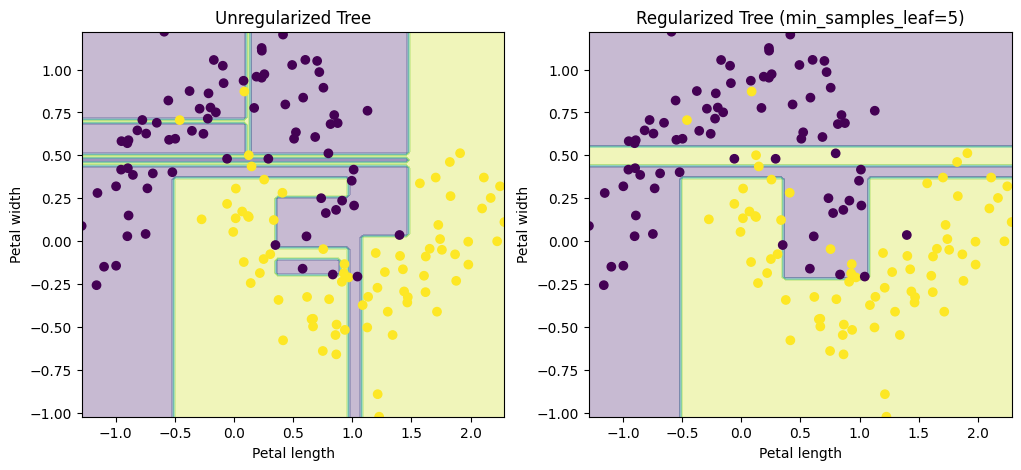

In [37]:
# Q3(c)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Unregularized
plt.subplot(1,2,1)
plot_decision_boundary(tree_clf_unreg, X_moons, y_moons)
plt.title("Unregularized Tree")

# Regularized
plt.subplot(1,2,2)
plot_decision_boundary(tree_clf_reg, X_moons, y_moons)
plt.title("Regularized Tree (min_samples_leaf=5)")

plt.show()

The unregularized decision tree produces a more complex and fragmented decision boundary, indicating that it is trying to fit the training data very closely. This behavior leads to overfitting, as the model captures noise and small variations in the dataset.

On the other hand, the regularized model (min_samples_leaf=5) creates a smoother and simpler decision boundary. By preventing the tree from splitting into very small regions, regularization reduces model complexity.

As a result, the regularized model has better generalization capability because it focuses on the overall data distribution rather than memorizing specific data points.

In [38]:
#Q4
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.30, random_state=0
)

tree_unreg = DecisionTreeClassifier(random_state=0)
tree_reg = DecisionTreeClassifier(min_samples_leaf=5, random_state=0)

tree_unreg.fit(X_train, y_train)
tree_reg.fit(X_train, y_train)

y_pred_unreg = tree_unreg.predict(X_test)
y_pred_reg = tree_reg.predict(X_test)

acc_unreg = accuracy_score(y_test, y_pred_unreg)
acc_reg = accuracy_score(y_test, y_pred_reg)

print("Unregularized test accuracy:", acc_unreg)
print("Regularized test accuracy:", acc_reg)

Unregularized test accuracy: 0.8666666666666667
Regularized test accuracy: 0.8


The unregularized model has better test accuracy (0.87) compared to the regularized model (0.80).

In this case, regularization did not improve the test accuracy. Although regularization generally helps prevent overfitting, here the unregularized model performed better on the test set.

This suggests that the regularized model may be too simple for this dataset, leading to slightly worse performance.

In [39]:
#Q5(a)
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, train_test_split

iris = load_iris()
X_full = iris.data
y_full = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.20, random_state=0
)

param_grid = {
    "max_depth": [2, 5, 10],
    "min_samples_leaf": [1, 5, 20]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best parameters: {'max_depth': 5, 'min_samples_leaf': 1}
Best CV accuracy: 0.9416666666666668


The best hyperparameter combination is max_depth=5 and min_samples_leaf=1.

This combination gives the highest cross-validation accuracy of 0.9417.

In [40]:
#Q5(b)
best_tree = DecisionTreeClassifier(
    max_depth=grid_search.best_params_["max_depth"],
    min_samples_leaf=grid_search.best_params_["min_samples_leaf"],
    random_state=0
)

default_tree = DecisionTreeClassifier(random_state=0)

best_tree.fit(X_train, y_train)
default_tree.fit(X_train, y_train)

best_test_acc = accuracy_score(y_test, best_tree.predict(X_test))
default_test_acc = accuracy_score(y_test, default_tree.predict(X_test))

print("Optimized model test accuracy:", best_test_acc)
print("Default model test accuracy:", default_test_acc)

Optimized model test accuracy: 1.0
Default model test accuracy: 1.0


Both the optimized model and the default model achieved the same test accuracy (1.0).

In this case, hyperparameter optimization did not improve the test accuracy. Although the optimized parameters were selected based on cross-validation, they did not provide additional benefit on the test set.